In [1]:
import numpy as np
from matplotlib import pyplot as plt
#%matplotlib inline
#%config InlineBackend.figure_format='retina'
import scipy.stats
from scipy.stats import norm

You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L05_frequentist.ipynb)

We generate $N$ Gaussian variables with $\mu=1$ in a.u. and $\sigma$ drawn from another Gaussian pdf with $\mu_\sigma=0.2$ and $\sigma_\sigma=0.05$, so as to implement the more generale case of heteroscedastic errors.

# Part I

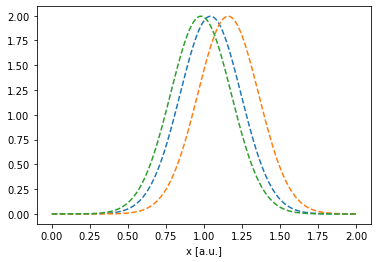

In [2]:
"""
generate N Gaussian variables
"""
mu_0=1
mu_sigma=0.2
sigma_sigma=0.05
N=3
#-----------------
"""
generate uncertainties
"""
#sigma=np.random.normal(mu_sigma,sigma_sigma,N) #for heteroscedastic errors
sigma=np.repeat(mu_sigma,N) #for homoscedastic errors
#-----------------
"""
generate measurements
"""
xi=np.concatenate([np.random.normal(mu_0,s) for s in zip(sigma)])
#-----------------
"""
plot the N likelihoods
"""
xgrid = np.linspace(0,2,1000)
y = np.array([norm.pdf(xgrid,loc=x_0,scale=s) for (x_0,s) in zip(xi,sigma)])
#-----------------
fig, ax = plt.subplots()
#figsize=(5, 5)
for yi in y:
    plt.plot(xgrid,yi,ls='--')
plt.xlabel('x [a.u.]')
plt.show()

We compute the likelihood letting the parameter $\mu$ take discrete values along the $\mu$-axis and assuming the $N$ uncertainties $\sigma_i$ to be known and homogeneous (homoscedasticity):

$$L(\mu) = \prod_i^N p(x_i|\mu)$$

We define a ($N,M$)-array: $N$ likelihoods for each of the $M$ values we let $\mu$ vary over

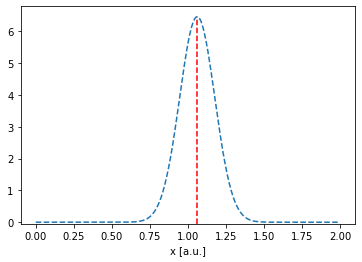

L(μ) attains maximum at μ = 1.06


In [3]:
mu_grid = np.linspace(0,2,1000) #points on the μ parameter space
p_i=[norm.pdf(xi, loc=mu_var, scale=sigma) for mu_var in mu_grid] #array containing the single likelihoods to be multiplied, starting at μ=0
P=np.prod(p_i,axis=1)#multiply each of the N likelihoods at fixed μ

#-----------------

vertical_axis_min = -0.05 #bottom edge of the canvas
fig, ax = plt.subplots()
plt.plot(xgrid,P,ls='--') #likelihood L(μ) plot

x_vertical_line = np.repeat(xgrid[np.argsort(P)[len(P)-1]],1000) #x coordinates of the points used to create the vertical line
y_vertical_line = np.linspace(vertical_axis_min,np.max(P),1000) #y coordinates of the points used to create the vertical line

plt.plot(x_vertical_line,y_vertical_line,ls='--',color='red') #vertical-line plot
plt.xlabel('x [a.u.]')
plt.ylim(ymin=vertical_axis_min)
plt.show()

#-----------------

print(f'L(μ) attains maximum at μ = {xgrid[np.argsort(P)[len(P)-1]]:.2f}')